# 用 SINDy 从数据中辨识 Lorenz 方程（对应书中 §4.3 / Algorithm 7 STLS）

$$\dot X = \Theta(X)\,\Xi,\qquad
\Xi = \arg\min_\Xi \|\dot X - \Theta(X)\Xi\|_2^2\ \ \text{（顺序阈值最小二乘，稀疏化）}$$

真实系统：$\dot x = \sigma(y-x),\ \ \dot y = x(\rho-z)-y,\ \ \dot z = xy-\beta z$，
$(\sigma,\rho,\beta)=(10,\,28,\,8/3)$。

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

sigma, rho, beta = 10.0, 28.0, 8.0 / 3.0

def lorenz(s):
    x, y, z = s
    return np.array([sigma * (y - x), x * (rho - z) - y, x * y - beta * z])

def rk4(f, s0, dt, n):
    traj = np.zeros((n, len(s0)))
    s = np.array(s0, dtype=float)
    for i in range(n):
        traj[i] = s
        k1 = f(s); k2 = f(s + dt / 2 * k1)
        k3 = f(s + dt / 2 * k2); k4 = f(s + dt * k3)
        s = s + dt / 6 * (k1 + 2 * k2 + 2 * k3 + k4)
    return traj

dt, n = 0.002, 25000
X = rk4(lorenz, [-8.0, 8.0, 27.0], dt, n)
dX = np.gradient(X, dt, axis=0)          # 中心差分近似导数

In [2]:
def poly_library(X, degree=2):
    """多项式候选函数库 Theta(X)，最高 2 次。"""
    x, y, z = X.T
    cols = [np.ones(len(X)), x, y, z,
            x * x, x * y, x * z, y * y, y * z, z * z]
    names = ["1", "x", "y", "z", "xx", "xy", "xz", "yy", "yz", "zz"]
    return np.stack(cols, axis=1), names


def stls(Theta, dX, lam=0.1, n_iter=10):
    """顺序阈值最小二乘（Algorithm 7）。"""
    Xi = np.linalg.lstsq(Theta, dX, rcond=None)[0]
    for _ in range(n_iter):
        Xi[np.abs(Xi) < lam] = 0
        for k in range(dX.shape[1]):
            big = np.abs(Xi[:, k]) >= lam
            if big.any():
                Xi[big, k] = np.linalg.lstsq(Theta[:, big], dX[:, k], rcond=None)[0]
    return Xi


Theta, names = poly_library(X)
Xi = stls(Theta, dX, lam=0.1)

print("辨识结果（非零项）:")
for k, var in enumerate(["dx/dt", "dy/dt", "dz/dt"]):
    terms = [f"{Xi[j, k]:+.3f} {names[j]}" for j in range(len(names)) if Xi[j, k] != 0]
    print(f"  {var} = " + "  ".join(terms))
print("\n真值:  dx/dt = -10 x +10 y   dy/dt = +28 x -1 y -1 xz   dz/dt = -2.667 z +1 xy")

辨识结果（非零项）:
  dx/dt = -9.999 x  +9.999 y
  dy/dt = +27.992 x  -0.999 y  -1.000 xz
  dz/dt = -2.666 z  +1.000 xy

真值:  dx/dt = -10 x +10 y   dy/dt = +28 x -1 y -1 xz   dz/dt = -2.667 z +1 xy


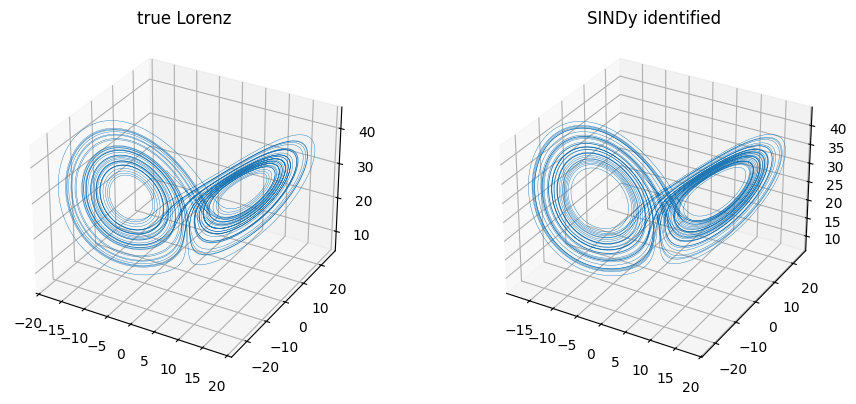

系数最大误差: 0.0077


In [3]:
def identified(s):
    th, _ = poly_library(s.reshape(1, -1))
    return (th @ Xi).flatten()

X_id = rk4(identified, X[0], dt, n)

fig = plt.figure(figsize=(10, 4))
for i, (traj, title) in enumerate([(X, "true Lorenz"), (X_id, "SINDy identified")]):
    ax = fig.add_subplot(1, 2, i + 1, projection="3d")
    ax.plot(traj[:, 0], traj[:, 1], traj[:, 2], lw=0.3)
    ax.set_title(title)
plt.tight_layout(); plt.show()

print("系数最大误差:", np.abs(Xi - np.round(Xi * 3) / 3).max().round(4))